<a href="https://colab.research.google.com/github/Keshavgoyal14/Robotics-Project/blob/main/Robotics_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import zipfile

zip_path = "/content/drive/MyDrive/cnn_classification_dataset.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extracted to /content/")

✅ Extracted to /content/


In [6]:
import zipfile

zip_path = "/content/drive/MyDrive/merged_aluminium_non_aluminium.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extracted to /content/")

✅ Extracted to /content/


In [7]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.5 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data="/content/merged_aluminium_non_aluminium/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    workers=4
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_aluminium_non_aluminium/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f2f500ec620>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [9]:
# ==============================
# 1️⃣ Imports
# ==============================
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# ==============================
# 2️⃣ Device
# ==============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ==============================
# 3️⃣ Dataset Paths (YOUR DATA)
# ==============================
train_dir = "/content/cnn_classification_dataset/train"
val_dir   = "/content/cnn_classification_dataset/valid"
test_dir  = "/content/cnn_classification_dataset/test"

# ==============================
# 4️⃣ Transforms
# ==============================
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ==============================
# 5️⃣ Load Data
# ==============================
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data   = datasets.ImageFolder(val_dir, transform=val_transform)
test_data  = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

print("Classes:", train_data.classes)

# ==============================
# 6️⃣ Model (BEST)
# ==============================
model = torchvision.models.convnext_tiny(weights="IMAGENET1K_V1")

model.classifier[2] = nn.Linear(
    model.classifier[2].in_features, 2
)

model = model.to(device)

# ==============================
# 7️⃣ Loss & Optimizer
# ==============================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0003)

# ==============================
# 8️⃣ Mixed Precision
# ==============================
scaler = torch.cuda.amp.GradScaler()

# ==============================
# 9️⃣ Training Loop
# ==============================
epochs = 25

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    # ==========================
    # Validation
    # ==========================
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {running_loss:.4f} "
          f"Val Acc: {val_acc:.4f}")

# ==============================
# 🔟 Test Evaluation
# ==============================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("🔥 Test Accuracy:", correct / total)

# ==============================
# Save Model
# ==============================
torch.save(model.state_dict(), "/content/aluminium_cnn_best.pth")

print("✅ Model saved!")

Using device: cuda
Classes: ['aluminium', 'non_aluminium']
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 189MB/s] 
/tmp/ipykernel_2577/2472993003.py:77: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_2577/2472993003.py:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/25] Loss: 13.4096 Val Acc: 0.9244
Epoch [2/25] Loss: 6.3781 Val Acc: 0.9395
Epoch [3/25] Loss: 4.1024 Val Acc: 0.9225
Epoch [4/25] Loss: 4.6347 Val Acc: 0.9565
Epoch [5/25] Loss: 3.7714 Val Acc: 0.9319
Epoch [6/25] Loss: 3.7008 Val Acc: 0.9414
Epoch [7/25] Loss: 2.2853 Val Acc: 0.9376
Epoch [8/25] Loss: 3.4265 Val Acc: 0.8922
Epoch [9/25] Loss: 1.4973 Val Acc: 0.9112
Epoch [10/25] Loss: 2.2187 Val Acc: 0.9735
Epoch [11/25] Loss: 2.0505 Val Acc: 0.8639
Epoch [12/25] Loss: 2.1315 Val Acc: 0.8885
Epoch [13/25] Loss: 2.4799 Val Acc: 0.9471
Epoch [14/25] Loss: 1.5774 Val Acc: 0.9074
Epoch [15/25] Loss: 2.9577 Val Acc: 0.8922
Epoch [16/25] Loss: 1.7797 Val Acc: 0.8885
Epoch [17/25] Loss: 1.5085 Val Acc: 0.9471
Epoch [18/25] Loss: 2.9736 Val Acc: 0.8885
Epoch [19/25] Loss: 2.6074 Val Acc: 0.9546
Epoch [20/25] Loss: 1.7910 Val Acc: 0.9395
Epoch [21/25] Loss: 1.0880 Val Acc: 0.9319
Epoch [22/25] Loss: 1.0092 Val Acc: 0.9206
Epoch [23/25] Loss: 0.8132 Val Acc: 0.9206
Epoch [24/25] Loss:

In [10]:
import os

save_path = "/content/drive/MyDrive/Aluminium_Project"
os.makedirs(save_path, exist_ok=True)

In [11]:
import shutil

yolo_src = "/content/runs/detect/train/weights/best.pt"
yolo_dst = "/content/drive/MyDrive/Aluminium_Project/yolo_best.pt"

shutil.copy(yolo_src, yolo_dst)

print("✅ YOLO model saved to Drive")

✅ YOLO model saved to Drive


In [12]:
cnn_src = "/content/aluminium_cnn_best.pth"
cnn_dst = "/content/drive/MyDrive/Aluminium_Project/cnn_best.pth"

shutil.copy(cnn_src, cnn_dst)

print("✅ CNN model saved to Drive")

✅ CNN model saved to Drive


In [13]:
os.listdir("/content/drive/MyDrive/Aluminium_Project")

['YOLO', 'CNN', 'yolo_best.pt', 'cnn_best.pth']

Using device: cuda

0: 640x640 2 aluminiums, 36.8ms
Speed: 2.8ms preprocess, 36.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


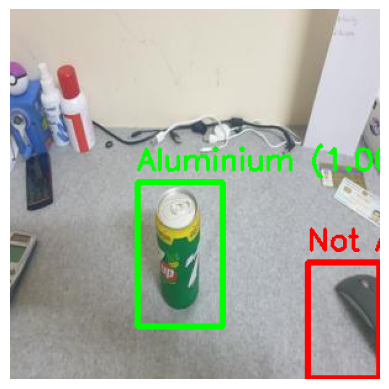

In [15]:
import cv2
import torch
import torchvision
from torchvision import transforms
from torch import nn
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

# ==============================
# 1️⃣ Device
# ==============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ==============================
# 2️⃣ Load YOLO
# ==============================
yolo_model = YOLO("/content/runs/detect/train/weights/best.pt")

# ==============================
# 3️⃣ Load CNN
# ==============================
cnn_model = torchvision.models.convnext_tiny(weights=None)

cnn_model.classifier[2] = nn.Linear(
    cnn_model.classifier[2].in_features, 2
)

cnn_model.load_state_dict(torch.load("/content/aluminium_cnn_best.pth", map_location=device))
cnn_model.to(device)
cnn_model.eval()

# ==============================
# 4️⃣ Transform
# ==============================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

classes = ["Aluminium", "Not Aluminium"]

# ==============================
# 5️⃣ Load Test Image
# ==============================
image_path = "/content/cnn_classification_dataset/test/aluminium/aluminium_Aluminium.v2i.yolov8-obb_20220211_192822_jpg.rf.5e1ce269ae536806f8c7e2efc4504ffa.jpg"   # 🔥 change this
frame = cv2.imread(image_path)

# ==============================
# 6️⃣ YOLO Detection
# ==============================
results = yolo_model(frame)

for r in results:
    boxes = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()

    for box, conf in zip(boxes, confs):

        if conf < 0.5:
            continue

        x1, y1, x2, y2 = map(int, box)

        crop = frame[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        # CNN classification
        rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(rgb)
        input_tensor = transform(pil_img).unsqueeze(0).to(device)

        with torch.no_grad():
            output = cnn_model(input_tensor)
            probs = torch.softmax(output, dim=1)
            class_idx = probs.argmax().item()
            confidence = probs[0][class_idx].item()

        label = classes[class_idx]

        # Draw box
        color = (0,255,0) if label == "Aluminium" else (0,0,255)
        cv2.rectangle(frame, (x1,y1), (x2,y2), color, 3)

        text = f"{label} ({confidence:.2f})"
        cv2.putText(frame, text, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, color, 2)

# ==============================
# 7️⃣ Show Result
# ==============================
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()